# Milan Mobile Traffic Forecasting — Part 3: Forecasting Models & Experiments

Implements and compares **three sequential models** for one-step-ahead forecasting of Internet
traffic, evaluated on the week of **16–22 December 2013**:

| Model | Family | Why it is here |
|---|---|---|
| **SARIMA** | Linear statistical | The literature's reference point; interpretable; built for the seasonal-plus-trend structure the EDA found |
| **LSTM** | Recurrent neural | The default in mobile-traffic forecasting; gating spans a long window without vanishing gradients |
| **TCN** | Convolutional neural | Reaches comparable context by dilated causal convolution — parallel in time, a genuinely different inductive bias |

Plus two naive references — **persistence** and **seasonal naive** — which are *not* among the three
but without which the accuracy claims would be unanchored.

> **Runtime:** set **Runtime → Change runtime type → T4 GPU** before running. The neural models
> train far faster on GPU; SARIMA is CPU-bound either way.

In [1]:
!pip -q install pyarrow statsmodels

import os, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PROJECT_DIR = "/content/drive/MyDrive/milan_traffic_project"
FIG_DIR = os.path.join(DRIVE_PROJECT_DIR, "figures")
RES_DIR = os.path.join(DRIVE_PROJECT_DIR, "results")
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(RES_DIR, exist_ok=True)

warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
warnings.filterwarnings("ignore", message=".*Maximum Likelihood optimization failed.*")

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
                     "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "semibold",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False})
PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00"]
ACTUAL, PREDICTED = "#333333", "#D55E00"
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=PALETTE)

def save(fig, name):
    p = os.path.join(FIG_DIR, f"{name}.png"); fig.savefig(p); return p

gpus = tf.config.list_physical_devices("GPU")
print(f"TensorFlow {tf.__version__} | GPU: {[g.name for g in gpus] if gpus else 'NONE (CPU only)'}")
if not gpus:
    print("  -> Runtime > Change runtime type > T4 GPU  for much faster neural training")

Mounted at /content/drive
TensorFlow 2.20.0 | GPU: ['/physical_device:GPU:0']


## 1. Load data and define the forecasting protocol

In [2]:
areas_df = pd.read_parquet(os.path.join(DRIVE_PROJECT_DIR, "areas_of_interest.parquet"))
meta = json.load(open(os.path.join(DRIVE_PROJECT_DIR, "meta.json")))
TOP3, AREAS = meta["top3"], meta["areas"]
SLOTS_PER_DAY, WEEK = 144, 1008
SEED = 42

def series(square_id):
    s = areas_df[areas_df.SquareId == square_id].set_index("Timestamp")["Internet"]
    return s.astype("float64").sort_index()

FOCUS = TOP3[0]
full_index = series(FOCUS).index
print(f"areas: {AREAS} | focus area for tuning: {FOCUS}")
print(f"span : {full_index[0]} -> {full_index[-1]} ({len(full_index):,} intervals)")

areas: [5161, 5059, 5259, 4159, 4556] | focus area for tuning: 5161
span : 2013-11-01 00:00:00+01:00 -> 2014-01-01 23:50:00+01:00 (8,928 intervals)


### The protocol

At time *t* the model receives the observed history up to and including *t* and predicts *x(t+1)*.
This is **rolling one-step-ahead with observed history**, not recursive multi-step — errors never
compound.

That single fact shapes the whole study: it is *why* persistence is competitive, and why beating it
by a few percent is a modest achievement rather than an impressive one.

Splits are strictly chronological — shuffling a time series leaks the future into the past.
Hyperparameters are chosen on a **tuning split shifted one week earlier**, so the reported week
plays no part in model selection. Reusing the early-stopping week for selection would be a mild but
real form of selection bias.

In [3]:
def slot_of(ts):
    return int(np.searchsorted(full_index, pd.Timestamp(ts, tz=full_index.tz)))

TEST_LO, TEST_HI = slot_of("2013-12-16 00:00"), slot_of("2013-12-22 23:50") + 1
VAL_LO = TEST_LO - WEEK

FINAL_SPLIT  = {"train": (0, VAL_LO), "val": (VAL_LO, TEST_LO), "test": (TEST_LO, TEST_HI)}
TUNING_SPLIT = {"train": (0, VAL_LO - WEEK), "val": (VAL_LO - WEEK, VAL_LO), "test": (VAL_LO, TEST_LO)}

def describe(split, name):
    rows = [{"split": k, "start": full_index[lo], "end": full_index[hi-1],
             "slots": hi-lo, "days": (hi-lo)/SLOTS_PER_DAY} for k, (lo, hi) in split.items()]
    print(f"\n{name}:"); print(pd.DataFrame(rows).to_string(index=False))

describe(FINAL_SPLIT, "FINAL split (reported once)")
describe(TUNING_SPLIT, "TUNING split (all hyperparameter decisions)")
assert TUNING_SPLIT["test"][1] <= FINAL_SPLIT["test"][0], "tuning must not overlap the reported week"
print(f"\nOK: tuning ends {full_index[TUNING_SPLIT['test'][1]-1]}, "
      f"reported week starts {full_index[FINAL_SPLIT['test'][0]]}")


FINAL split (reported once):
split                     start                       end  slots  days
train 2013-11-01 00:00:00+01:00 2013-12-08 23:50:00+01:00   5472  38.0
  val 2013-12-09 00:00:00+01:00 2013-12-15 23:50:00+01:00   1008   7.0
 test 2013-12-16 00:00:00+01:00 2013-12-22 23:50:00+01:00   1008   7.0

TUNING split (all hyperparameter decisions):
split                     start                       end  slots  days
train 2013-11-01 00:00:00+01:00 2013-12-01 23:50:00+01:00   4464  31.0
  val 2013-12-02 00:00:00+01:00 2013-12-08 23:50:00+01:00   1008   7.0
 test 2013-12-09 00:00:00+01:00 2013-12-15 23:50:00+01:00   1008   7.0

OK: tuning ends 2013-12-15 23:50:00+01:00, reported week starts 2013-12-16 00:00:00+01:00


### Metrics

In [4]:
EPS = 1e-8

def mae(y, p):  return float(np.mean(np.abs(y - p)))
def rmse(y, p): return float(np.sqrt(np.mean((y - p)**2)))

def mape(y, p):
    """MAPE is unstable where the target approaches zero -- here the 03:00-05:00 trough --
    so it is computed only where |y| > EPS, and the coverage is reported alongside."""
    m = np.abs(y) > EPS
    return float(np.mean(np.abs((y[m]-p[m])/y[m]))*100) if m.any() else np.nan

def smape(y, p):
    d = (np.abs(y)+np.abs(p))/2; m = d > EPS
    return float(np.mean(np.abs(y[m]-p[m])/d[m])*100) if m.any() else np.nan

def r2(y, p):
    ss = np.sum((y-y.mean())**2)
    return float(1 - np.sum((y-p)**2)/ss) if ss > EPS else np.nan

def skill(y, p, baseline):
    """Fractional RMSE improvement over a baseline. Positive = better than the baseline.
    Reported because at this horizon persistence is strong enough that raw MAE alone misleads."""
    return float(1 - rmse(y, p)/max(rmse(y, baseline), EPS))

def all_metrics(y, p, baseline=None):
    y, p = np.asarray(y, float).ravel(), np.asarray(p, float).ravel()
    out = {"MAE": mae(y,p), "RMSE": rmse(y,p), "MAPE_%": mape(y,p),
           "sMAPE_%": smape(y,p), "R2": r2(y,p),
           "MAPE_coverage": float(np.mean(np.abs(y) > EPS))}
    if baseline is not None:
        out["skill_vs_persistence"] = skill(y, p, np.asarray(baseline, float).ravel())
    return out

### Windowing and scaling

In [5]:
def make_windows(values, lookback):
    """Sliding windows. X[i] holds the `lookback` values ending at target_idx[i]-1,
    and y[i] is the value at target_idx[i] -- the window never contains its own target."""
    v = np.asarray(values, np.float32).ravel()
    X = np.lib.stride_tricks.sliding_window_view(v, lookback)[:-1]
    return X, v[lookback:], np.arange(lookback, len(v))

class Scaler:
    """Standardisation, optionally on a log1p scale. Fitted on TRAINING TARGETS ONLY."""
    def __init__(self, log=False): self.log, self.mean_, self.std_ = log, 0.0, 1.0
    def fit(self, v):
        v = np.asarray(v, np.float64)
        if self.log: v = np.log1p(np.clip(v, 0, None))
        self.mean_, self.std_ = float(v.mean()), float(v.std()) or 1.0
        return self
    def transform(self, v):
        v = np.asarray(v, np.float64)
        if self.log: v = np.log1p(np.clip(v, 0, None))
        return (v - self.mean_)/self.std_
    def inverse(self, v):
        v = np.asarray(v, np.float64)*self.std_ + self.mean_
        if self.log: v = np.expm1(np.clip(v, None, 50.0))
        return np.clip(v, 0.0, None)    # traffic cannot be negative

def build_dataset(values, lookback, split, log=False):
    X, y, idx = make_windows(values, lookback)
    sel = lambda b: (idx >= b[0]) & (idx < b[1])
    m_tr, m_va, m_te = sel(split["train"]), sel(split["val"]), sel(split["test"])
    sc = Scaler(log=log).fit(y[m_tr])          # training targets only -- no leakage
    raw = np.asarray(values, np.float64).ravel()
    return {"scaler": sc,
            "X_train": sc.transform(X[m_tr]).astype("float32"), "y_train": sc.transform(y[m_tr]).astype("float32"),
            "X_val":   sc.transform(X[m_va]).astype("float32"), "y_val":   sc.transform(y[m_va]).astype("float32"),
            "X_test":  sc.transform(X[m_te]).astype("float32"),
            "y_test_raw": raw[idx[m_te]], "test_idx": idx[m_te]}

def set_seeds(seed=SEED):
    import random
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); keras.utils.set_random_seed(seed)

# Contract check -- a window must never contain its own target.
_v = np.arange(100, dtype=np.float32)
_X, _y, _i = make_windows(_v, 5)
assert np.array_equal(_X[0], [0,1,2,3,4]) and _y[0] == 5 and _i[0] == 5
assert np.all(_X[:, -1] == _y - 1)
print("windowing contract OK")

windowing contract OK


## 2. Naive baselines — the bar every model must clear

In [6]:
def persistence(values, split):
    lo, hi = split["test"]; return np.asarray(values, float)[lo-1:hi-1]

def seasonal_naive(values, split, season=SLOTS_PER_DAY):
    lo, hi = split["test"]; return np.asarray(values, float)[lo-season:hi-season]

vals = series(FOCUS).to_numpy()
lo, hi = TUNING_SPLIT["test"]; truth_tune = vals[lo:hi]
base_p = persistence(vals, TUNING_SPLIT)

baseline_rows = []
for name, pred in [("Persistence", base_p), ("SeasonalNaive", seasonal_naive(vals, TUNING_SPLIT))]:
    m = all_metrics(truth_tune, pred, base_p); baseline_rows.append({"model": name, **m})
    print(f"  {name:<16s} RMSE={m['RMSE']:8.3f} MAE={m['MAE']:8.3f} "
          f"MAPE={m['MAPE_%']:6.2f}% R2={m['R2']:.4f}")
pd.DataFrame(baseline_rows).round(4)

  Persistence      RMSE= 175.191 MAE= 116.833 MAPE=  9.46% R2=0.9867
  SeasonalNaive    RMSE= 525.493 MAE= 294.894 MAPE= 18.33% R2=0.8807


,model,MAE,RMSE,MAPE_%,sMAPE_%,R2,MAPE_coverage,skill_vs_persistence
0,Persistence,116.8333,175.1906,9.4630,9.3747,0.9867,1.0,0.0000
1,SeasonalNaive,294.8942,525.4935,18.3336,17.6554,0.8807,1.0,-1.9996


**Discussion.** Persistence explains around 99% of the variance on its own, and **seasonal naive is
several times worse**. At a ten-minute horizon, "ten minutes ago" is far more informative than "same
time yesterday" — which is exactly what the ACF in notebook 2 predicted (lag 1 ≈ 0.99 versus
lag 144 ≈ 0.88).

Every trained model below is therefore reported with a **skill score against persistence**. A model
that cannot clear it has not earned its complexity.

## 3. Model 1 — SARIMA

### Structure, input representation and training

SARIMA models the series directly, with no windowing: a Kalman filter carries the state forward and
each one-step-ahead prediction is conditioned on true history up to *t*.

**The seasonal period is a genuine engineering problem.** The daily cycle is *s* = 144 intervals.
Representing that seasonal difference inside `statsmodels`' state space costs **146 state
dimensions**, and the Kalman covariance update is cubic in the state — a single fit did not complete
in ten minutes on a CPU. Setting `simple_differencing=True` avoids the blow-up but then returns
predictions on the *differenced* scale and mis-aligns the boundary when new observations are
appended.

This notebook therefore applies the seasonal difference **explicitly**:

$$z(t) = x(t) - x(t-s)$$

fits a non-seasonal ARIMA to *z*, and inverts by adding *x(t−s)* back. That is the same model as
SARIMA(p,d,q)(0,1,0)[s], but every step is visible and testable.

`fourier_terms` implements the alternative Hyndman & Athanasopoulos recommend for long seasonal
periods: leave the series undifferenced and supply deterministic harmonic regressors instead. The
EDA's standard-deviation comparison predicted this should win; Experiment 1.4 tests it.

In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fourier_features(n, period, k, offset=0):
    t = np.arange(offset, offset+n, dtype=np.float64)
    return np.column_stack([f(2*np.pi*i*t/period) for i in range(1, k+1) for f in (np.sin, np.cos)])

class Sarima:
    def __init__(self, order=(2,0,1), seasonal_period=SLOTS_PER_DAY, seasonal_diff=1,
                 log=False, fourier_terms=None, maxiter=50):
        assert not (fourier_terms and seasonal_diff), \
            "use either seasonal differencing or Fourier terms -- differencing already removes the cycle"
        self.order, self.s, self.D = tuple(order), seasonal_period, seasonal_diff
        self.log = log
        self.fourier_terms = {int(k): int(v) for k, v in (fourier_terms or {}).items()}
        self.maxiter, self.res_ = maxiter, None
        # Carry the constructor arguments explicitly. Reconstructing a model by
        # regex-parsing its display name works until a name format changes, and
        # then fails silently -- which is the worst kind of failure here.
        self.config = {"order": tuple(order), "seasonal_period": seasonal_period,
                       "seasonal_diff": seasonal_diff, "log": log,
                       "fourier_terms": dict(self.fourier_terms) or None, "maxiter": maxiter}

    @property
    def name(self):
        p,d,q = self.order
        if self.fourier_terms:
            h = "+".join(f"F{per}x{k}" for per, k in sorted(self.fourier_terms.items()))
            base = f"ARIMA({p},{d},{q})+{h}"
        else:
            base = f"SARIMA({p},{d},{q})(0,{self.D},0)[{self.s}]"
        return base + ("+log" if self.log else "")

    def _fwd(self, v): return np.log1p(np.clip(v,0,None)) if self.log else np.asarray(v,float)
    def _inv(self, v): return np.clip(np.expm1(np.clip(v,None,50.)),0,None) if self.log else np.asarray(v,float)
    def _diff(self, v): return v[self.s:] - v[:-self.s] if self.D else v
    def _exog(self, n, off):
        if not self.fourier_terms: return None
        return np.column_stack([fourier_features(n, p, k, off)
                                for p, k in sorted(self.fourier_terms.items())])

    def fit(self, values, split):
        end = split["test"][0]
        z = self._diff(self._fwd(np.asarray(values, float)[:end]))
        off = self.s if self.D else 0
        model = SARIMAX(z, exog=self._exog(len(z), off), order=self.order,
                        enforce_stationarity=False, enforce_invertibility=False)
        self.k_states_ = int(model.k_states)
        self.res_ = model.fit(disp=False, maxiter=self.maxiter)
        self.aic_ = float(self.res_.aic)
        self.n_params = int(self.res_.params.shape[0])   # comparable to the neural counts
        return self

    def predict(self, values, split):
        v = np.asarray(values, float); lo, hi = split["test"]; n = hi - lo
        z_full = self._diff(self._fwd(v[:hi]))
        ext = self.res_.append(z_full[-n:], exog=self._exog(n, lo), refit=False)
        zhat = np.asarray(ext.get_prediction(start=ext.nobs-n, end=ext.nobs-1,
                                             dynamic=False).predicted_mean)
        xhat = zhat + self._fwd(v[lo-self.s:hi-self.s]) if self.D else zhat
        return np.clip(self._inv(xhat), 0, None)

### Verifying the protocol

A model that peeks at the future scores beautifully and forecasts nothing, and no other part of the
pipeline would catch it. So it is asserted, not assumed: perturb the series *after* a cut point and
check that predictions *before* it are unchanged — and that predictions after it *do* change, which
confirms the model is actually reading its history.

In [8]:
def check_no_lookahead(model, values, split, label):
    model.fit(values, split)
    base = model.predict(values, split)
    lo, hi = split["test"]; cut = (hi-lo)//2
    corrupted = np.asarray(values, float).copy(); corrupted[lo+cut:] += 1e5
    pert = model.predict(corrupted, split)
    head_ok = np.allclose(base[:cut], pert[:cut], rtol=1e-4, atol=1e-3)
    tail_ok = not np.allclose(base[cut:], pert[cut:], rtol=1e-4, atol=1e-3)
    print(f"  {label:<26s} past forecasts unchanged: {head_ok} | responds to history: {tail_ok}")
    assert head_ok and tail_ok, f"{label} violates the one-step-ahead protocol"
    return base

_ = check_no_lookahead(Sarima(order=(1,0,0)), vals, TUNING_SPLIT, "SARIMA")
print("SARIMA conditions on observed past only.")

  SARIMA                     past forecasts unchanged: True | responds to history: True
SARIMA conditions on observed past only.


### Experiment log

Every configuration is recorded with the reasoning that motivated it, written **at launch time**
rather than reconstructed afterwards.

In [9]:
EXPERIMENTS = []

def run_experiment(model, values, split, area, experiment, stage, rationale, verbose=True):
    lo, hi = split["test"]; truth = np.asarray(values, float)[lo:hi]
    t0 = time.time(); model.fit(values, split); train_s = time.time()-t0
    t0 = time.time(); preds = model.predict(values, split); pred_s = time.time()-t0
    m = all_metrics(truth, preds, persistence(values, split))
    rec = {"experiment": experiment, "stage": stage, "model": model.name, "area": area,
           **m, "train_s": round(train_s,2), "predict_s": round(pred_s,3),
           "n_params": getattr(model, "n_params", None), "epochs": getattr(model, "epochs_run_", None),
           "rationale": rationale, "config": dict(getattr(model, "config", {}))}
    EXPERIMENTS.append(rec)
    if verbose:
        print(f"  {model.name:<34s} RMSE={m['RMSE']:8.3f} MAE={m['MAE']:8.3f} "
              f"skill={m['skill_vs_persistence']:+.3f} ({train_s:.0f}s)")
    return rec, preds

def stage_table(experiment, stage=None):
    df = pd.DataFrame([e for e in EXPERIMENTS
                       if e["experiment"] == experiment and (stage is None or e["stage"] == stage)])
    return df.sort_values("RMSE").reset_index(drop=True)

#### Experiment 1.1 — Fix the differencing scheme first

*Rationale:* differencing changes what the ARIMA terms are modelling, so tuning (p,q) before it
would tune against a moving target. The EDA found the raw series already stationary by both ADF and
KPSS, and first differencing shrinking the spread far more than seasonal differencing — so the
expectation is that heavy seasonal differencing will **not** help.

In [10]:
R = "Fix differencing first: it changes what the ARIMA terms model, so tuning (p,q) before it tunes against a moving target."
for cfg in [{"order":(1,0,0),"seasonal_diff":1}, {"order":(1,0,0),"seasonal_diff":0},
            {"order":(1,1,0),"seasonal_diff":0}]:
    run_experiment(Sarima(**cfg), vals, TUNING_SPLIT, FOCUS, "sarima", "1.1", R)
stage_table("sarima", "1.1")[["model","RMSE","MAE","skill_vs_persistence","train_s"]].round(3)

  SARIMA(1,0,0)(0,1,0)[144]          RMSE= 227.511 MAE= 147.902 skill=-0.299 (0s)
  SARIMA(1,0,0)(0,0,0)[144]          RMSE= 175.444 MAE= 117.297 skill=-0.001 (0s)
  SARIMA(1,1,0)(0,0,0)[144]          RMSE= 178.208 MAE= 119.779 skill=-0.017 (0s)


,model,RMSE,MAE,skill_vs_persistence,train_s
0,"SARIMA(1,0,0)(0,0,0)[144]",175.444,117.297,-0.001,0.21
1,"SARIMA(1,1,0)(0,0,0)[144]",178.208,119.779,-0.017,0.05
2,"SARIMA(1,0,0)(0,1,0)[144]",227.511,147.902,-0.299,0.23


#### Experiment 1.2 — Grid over the non-seasonal (p, d, q) orders

*Rationale:* the PACF in notebook 2 decays over a few lags, so search low orders; higher orders
mainly cost fitting time.

In [11]:
BEST_DIFF = {k: v for k, v in json.loads(stage_table("sarima","1.1").iloc[0]["model"] and "{}" or "{}").items()}
best_11 = stage_table("sarima", "1.1").iloc[0]["model"]
SEASONAL_DIFF = 0 if "(0,0,0)" in best_11 else 1
D_ORDER = 1 if ",1,0)" in best_11.split(")")[0] else 0
print(f"carried forward: seasonal_diff={SEASONAL_DIFF}, d={D_ORDER}")

R = "The PACF cuts off after a few lags, so search low orders; higher orders mainly cost fitting time."
for order in [(1,D_ORDER,0),(2,D_ORDER,0),(2,D_ORDER,1),(3,D_ORDER,1),(2,D_ORDER,2),(3,D_ORDER,2)]:
    run_experiment(Sarima(order=order, seasonal_diff=SEASONAL_DIFF), vals, TUNING_SPLIT, FOCUS,
                   "sarima", "1.2", R)
stage_table("sarima", "1.2")[["model","RMSE","MAE","skill_vs_persistence","train_s"]].round(3)

carried forward: seasonal_diff=0, d=0
  SARIMA(1,0,0)(0,0,0)[144]          RMSE= 175.444 MAE= 117.297 skill=-0.001 (0s)
  SARIMA(2,0,0)(0,0,0)[144]          RMSE= 178.228 MAE= 119.310 skill=-0.017 (1s)
  SARIMA(2,0,1)(0,0,0)[144]          RMSE= 180.722 MAE= 121.486 skill=-0.032 (2s)
  SARIMA(3,0,1)(0,0,0)[144]          RMSE= 180.244 MAE= 120.992 skill=-0.029 (5s)
  SARIMA(2,0,2)(0,0,0)[144]          RMSE= 163.629 MAE= 110.129 skill=+0.066 (7s)
  SARIMA(3,0,2)(0,0,0)[144]          RMSE= 163.387 MAE= 109.617 skill=+0.067 (11s)


,model,RMSE,MAE,skill_vs_persistence,train_s
0,"SARIMA(3,0,2)(0,0,0)[144]",163.387,109.617,0.067,11.34
1,"SARIMA(2,0,2)(0,0,0)[144]",163.629,110.129,0.066,6.96
2,"SARIMA(1,0,0)(0,0,0)[144]",175.444,117.297,-0.001,0.23
3,"SARIMA(2,0,0)(0,0,0)[144]",178.228,119.310,-0.017,0.55
4,"SARIMA(3,0,1)(0,0,0)[144]",180.244,120.992,-0.029,4.80
5,"SARIMA(2,0,1)(0,0,0)[144]",180.722,121.486,-0.032,1.65


#### Experiment 1.3 — Harmonic regression versus seasonal differencing

*Rationale:* Hyndman & Athanasopoulos recommend harmonics over differencing for long seasonal
periods. Differencing is adaptive but **doubles the innovation variance** by combining two noisy
observations; harmonics are rigid but do not. The EDA's standard-deviation comparison predicted
harmonics should win here — this tests it directly.

In [12]:
import re
m = re.match(r"SARIMA\((\d),(\d),(\d)\)", stage_table("sarima","1.2").iloc[0]["model"])
BEST_ORDER = tuple(int(g) for g in m.groups()) if m else (3,0,2)
print("best order from 1.2:", BEST_ORDER)

R = ("Hyndman & Athanasopoulos recommend harmonics over differencing for long seasonal periods: "
     "differencing is adaptive but doubles innovation variance, harmonics are rigid but do not.")
run_experiment(Sarima(order=BEST_ORDER, seasonal_diff=SEASONAL_DIFF), vals, TUNING_SPLIT, FOCUS, "sarima", "1.3", R)
run_experiment(Sarima(order=BEST_ORDER, seasonal_diff=0, fourier_terms={SLOTS_PER_DAY:4}),
               vals, TUNING_SPLIT, FOCUS, "sarima", "1.3", R)
run_experiment(Sarima(order=BEST_ORDER, seasonal_diff=0, fourier_terms={SLOTS_PER_DAY:6, WEEK:2}),
               vals, TUNING_SPLIT, FOCUS, "sarima", "1.3", R)
run_experiment(Sarima(order=BEST_ORDER, seasonal_diff=0, fourier_terms={SLOTS_PER_DAY:4}, log=True),
               vals, TUNING_SPLIT, FOCUS, "sarima", "1.3", R)
stage_table("sarima", "1.3")[["model","RMSE","MAE","skill_vs_persistence","train_s"]].round(3)

best order from 1.2: (3, 0, 2)
  SARIMA(3,0,2)(0,0,0)[144]          RMSE= 163.387 MAE= 109.617 skill=+0.067 (5s)
  ARIMA(3,0,2)+F144x4                RMSE= 152.402 MAE= 101.936 skill=+0.130 (4s)
  ARIMA(3,0,2)+F144x6+F1008x2        RMSE= 152.669 MAE= 101.532 skill=+0.129 (7s)


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


  ARIMA(3,0,2)+F144x4+log            RMSE= 151.833 MAE= 101.083 skill=+0.133 (12s)


,model,RMSE,MAE,skill_vs_persistence,train_s
0,"ARIMA(3,0,2)+F144x4+log",151.833,101.083,0.133,12.06
1,"ARIMA(3,0,2)+F144x4",152.402,101.936,0.130,4.49
2,"ARIMA(3,0,2)+F144x6+F1008x2",152.669,101.532,0.129,6.61
3,"SARIMA(3,0,2)(0,0,0)[144]",163.387,109.617,0.067,4.81


**Discussion — record the actual numbers from the tables above.**

Expect three things to read off:
1. Whether seasonal differencing helped at all, and whether that matches the ADF/KPSS verdict in
   notebook 2. If the data and the test disagree, the test was measuring something the forecast does
   not care about.
2. How much the (p,d,q) order mattered *compared with* the differencing choice. If little, that
   bounds how much tuning effort ARIMA repays.
3. Whether harmonics beat differencing, as predicted.

In [13]:
def best_config(experiment, stage=None):
    """Configuration of the lowest-RMSE run, read from the log rather than re-parsed."""
    rows = [e for e in EXPERIMENTS
            if e["experiment"] == experiment and (stage is None or e["stage"] == stage)]
    return min(rows, key=lambda r: r["RMSE"])

best = best_config("sarima")
print(f"Best SARIMA: {best['model']}  (RMSE {best['RMSE']:.3f})")
print("  config:", best["config"])

SARIMA_CFG = {k: v for k, v in best["config"].items() if k != "seasonal_period"}
build_best_sarima = lambda: Sarima(**SARIMA_CFG)
print("  reconstructed ->", build_best_sarima().name)

Best SARIMA: ARIMA(3,0,2)+F144x4+log  (RMSE 151.833)
  config: {'order': (3, 0, 2), 'seasonal_period': 144, 'seasonal_diff': 0, 'log': True, 'fourier_terms': {144: 4}, 'maxiter': 50}
  reconstructed -> ARIMA(3,0,2)+F144x4+log


## 4. Models 2 and 3 — LSTM and TCN

Only the **architecture** differs between them. Input representation, scaling, optimiser,
early-stopping rule and evaluation protocol are held identical on purpose, so any gap is
attributable to the inductive bias rather than to one being tuned more carefully.

### Input representation (required by the brief)

| | SARIMA | LSTM / TCN |
|---|---|---|
| Input | Full history, differenced or with harmonic regressors | Sliding window of the last *L* observations |
| Sequence length | n/a — state-space filter | *L*, chosen in Experiments 2.1 / 3.1 |
| Preprocessing | Optional `log1p`; explicit lag-144 differencing | Optional `log1p` |
| Normalisation | None | Standardised; **statistics fitted on training targets only** |
| Tensor shape | `(n,)` | `(n, L, 1)` |

The single channel is the area's own Internet traffic: the task is defined as univariate, and adding
covariates would confound the architectural comparison.

In [14]:
class KerasForecaster:
    """Shared lifecycle. Subclasses supply `build()` only."""
    def __init__(self, lookback=SLOTS_PER_DAY, log=False, epochs=60, batch_size=64,
                 learning_rate=1e-3, patience=8, seed=SEED):
        self.lookback, self.log = lookback, log
        self.epochs, self.batch_size = epochs, batch_size
        self.learning_rate, self.patience, self.seed = learning_rate, patience, seed
        self.model_ = self.ds_ = self.epochs_run_ = None
        self.config = {"lookback": lookback, "log": log, "epochs": epochs,
                       "batch_size": batch_size, "learning_rate": learning_rate,
                       "patience": patience}

    def fit(self, values, split):
        set_seeds(self.seed)
        self.ds_ = build_dataset(values, self.lookback, split, log=self.log)
        self.model_ = self.build((self.lookback, 1))
        self.model_.compile(optimizer=keras.optimizers.Adam(self.learning_rate), loss="mse")
        cbs = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=self.patience,
                                             restore_best_weights=True, mode="min"),
               keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                                 patience=max(3, self.patience//3), min_lr=1e-5)]
        h = self.model_.fit(self.ds_["X_train"][..., None], self.ds_["y_train"],
                            validation_data=(self.ds_["X_val"][..., None], self.ds_["y_val"]),
                            epochs=self.epochs, batch_size=self.batch_size,
                            callbacks=cbs, shuffle=True, verbose=0)
        self.epochs_run_ = len(h.history["loss"])
        self.history_ = h.history
        self.n_params = int(self.model_.count_params())
        return self

    def predict(self, values, split):
        # Rebuild windows against the series handed in, so predict() stays a pure function
        # of its arguments -- which is what makes the leakage check valid.
        ds = build_dataset(values, self.lookback, split, log=self.log)
        sc = self.ds_["scaler"]
        v = np.asarray(values, np.float32).ravel()
        Xw = np.lib.stride_tricks.sliding_window_view(v, self.lookback)[:-1]
        X = sc.transform(Xw[ds["test_idx"] - self.lookback]).astype("float32")[..., None]
        return sc.inverse(self.model_.predict(X, batch_size=256, verbose=0).ravel())

class LSTMForecaster(KerasForecaster):
    def __init__(self, units=(64,), dropout=0.0, **kw):
        super().__init__(**kw); self.units, self.dropout = tuple(units), dropout
        self.config.update(units=tuple(units), dropout=dropout)
    @property
    def name(self):
        return f"LSTM({'-'.join(map(str,self.units))})@L{self.lookback}" + ("+log" if self.log else "")
    def build(self, shape):
        inp = keras.Input(shape=shape); x = inp
        for i, u in enumerate(self.units):
            x = layers.LSTM(u, return_sequences=(i < len(self.units)-1))(x)
            if self.dropout: x = layers.Dropout(self.dropout)(x)
        return keras.Model(inp, layers.Dense(1)(x), name="lstm")

class TCNForecaster(KerasForecaster):
    """Residual stack of dilated causal convolutions (Bai, Kolter & Koltun, 2018).

    Dilation doubles per block, so n blocks of kernel k see 1 + 2(k-1)(2^n - 1) steps.
    n_blocks=None picks the smallest depth whose receptive field covers the input window --
    there is no value in a model that structurally cannot see the history it is given."""
    def __init__(self, filters=64, kernel_size=3, n_blocks=None, dropout=0.1, **kw):
        super().__init__(**kw)
        self.filters, self.kernel_size, self.dropout = filters, kernel_size, dropout
        if n_blocks is None:
            n = 1
            while 1 + 2*(kernel_size-1)*(2**n - 1) < self.lookback and n < 12: n += 1
            n_blocks = n
        self.n_blocks = n_blocks
        self.config.update(filters=filters, kernel_size=kernel_size,
                           n_blocks=n_blocks, dropout=dropout)
    @property
    def receptive_field(self): return 1 + 2*(self.kernel_size-1)*(2**self.n_blocks - 1)
    @property
    def name(self):
        return (f"TCN(f{self.filters},k{self.kernel_size},b{self.n_blocks})@L{self.lookback}"
                + ("+log" if self.log else ""))
    def build(self, shape):
        inp = keras.Input(shape=shape); x = inp
        for i in range(self.n_blocks):
            skip = x
            for _ in range(2):
                x = layers.Conv1D(self.filters, self.kernel_size, padding="causal",
                                  dilation_rate=2**i, activation="relu")(x)
                if self.dropout: x = layers.SpatialDropout1D(self.dropout)(x)
            if skip.shape[-1] != self.filters:
                skip = layers.Conv1D(self.filters, 1, padding="same")(skip)
            x = layers.Activation("relu")(layers.Add()([skip, x]))
        # Causal padding means the last position has seen the whole window and nothing beyond it.
        x = layers.Lambda(lambda t: t[:, -1, :], output_shape=(self.filters,))(x)
        return keras.Model(inp, layers.Dense(1)(x), name="tcn")

for M, lbl in [(LSTMForecaster(units=(8,), lookback=36, epochs=1, patience=1), "LSTM"),
               (TCNForecaster(filters=8, lookback=36, epochs=1, patience=1), "TCN")]:
    _ = check_no_lookahead(M, vals, TUNING_SPLIT, lbl)
print("Both neural models honour the one-step-ahead protocol.")

  LSTM                       past forecasts unchanged: True | responds to history: True
  TCN                        past forecasts unchanged: True | responds to history: True
Both neural models honour the one-step-ahead protocol.


### Experiment 2.1 / 3.1 — How much history does each model need?

*Rationale:* lookback is the single most expensive hyperparameter — it scales the recurrent unroll,
the memory footprint and the convolutional depth — so fix it first with a deliberately small
network, then spend capacity where it pays.

The ACF in notebook 2 is dominated by the first few lags but has a clear secondary peak at lag 144.
If a model exploits the daily cycle, a full-day window should beat a short one; if one-step-ahead is
really a *local* problem, it will not. The two architectures may well answer differently.

In [15]:
SEARCH = dict(epochs=30, patience=5)
R = ("Lookback scales the unroll, the memory footprint and the convolutional depth, so fix it first "
     "with a small network, then spend capacity where it pays.")

for lb in (6, 36, 144):
    run_experiment(LSTMForecaster(units=(32,), lookback=lb, **SEARCH), vals, TUNING_SPLIT, FOCUS, "lstm", "2.1", R)
print()
for lb in (36, 144):
    run_experiment(TCNForecaster(filters=16, lookback=lb, **SEARCH), vals, TUNING_SPLIT, FOCUS, "tcn", "3.1", R)

pd.concat([stage_table("lstm","2.1"), stage_table("tcn","3.1")])[
    ["model","RMSE","MAE","skill_vs_persistence","train_s","epochs","n_params"]].round(3)

  LSTM(32)@L6                        RMSE= 169.065 MAE= 112.963 skill=+0.035 (15s)


  LSTM(32)@L36                       RMSE= 161.043 MAE= 110.998 skill=+0.081 (17s)
  LSTM(32)@L144                      RMSE= 157.978 MAE= 109.443 skill=+0.098 (20s)

  TCN(f16,k3,b4)@L36                 RMSE= 155.429 MAE= 104.171 skill=+0.113 (25s)
  TCN(f16,k3,b6)@L144                RMSE= 191.553 MAE= 131.021 skill=-0.093 (35s)


,model,RMSE,MAE,skill_vs_persistence,train_s,epochs,n_params
0,LSTM(32)@L144,157.978,109.443,0.098,20.20,23,4385
1,LSTM(32)@L36,161.043,110.998,0.081,16.71,30,4385
2,LSTM(32)@L6,169.065,112.963,0.035,15.07,30,4385
0,"TCN(f16,k3,b4)@L36",155.429,104.171,0.113,25.40,13,5601
1,"TCN(f16,k3,b6)@L144",191.553,131.021,-0.093,34.87,17,8737


### Experiment 2.2 / 3.2 — Capacity

*Rationale:* roughly 6,300 training windows from a single univariate series is very little data for a
neural network, so the sweep starts **below** the data's capacity and grows, rather than starting
oversized and regularising back down. Expect width to saturate early and the stacked variant to
overfit.

In [16]:
LB_LSTM = best_config("lstm", "2.1")["config"]["lookback"]
LB_TCN  = best_config("tcn",  "3.1")["config"]["lookback"]
print(f"carried forward: LSTM lookback={LB_LSTM}, TCN lookback={LB_TCN}")

R = ("~6,300 training windows from one series is little data, so sweep upward from small rather than "
     "starting oversized and regularising back down.")
for u in [(16,), (32,), (64,), (64,64)]:
    run_experiment(LSTMForecaster(units=u, lookback=LB_LSTM, **SEARCH), vals, TUNING_SPLIT, FOCUS, "lstm", "2.2", R)
print()
for f in (16, 32, 64):
    run_experiment(TCNForecaster(filters=f, lookback=LB_TCN, **SEARCH), vals, TUNING_SPLIT, FOCUS, "tcn", "3.2", R)

pd.concat([stage_table("lstm","2.2"), stage_table("tcn","3.2")])[
    ["model","RMSE","MAE","skill_vs_persistence","train_s","epochs","n_params"]].round(3)

carried forward: LSTM lookback=144, TCN lookback=36
  LSTM(16)@L144                      RMSE= 165.559 MAE= 113.132 skill=+0.055 (22s)
  LSTM(32)@L144                      RMSE= 157.978 MAE= 109.443 skill=+0.098 (19s)
  LSTM(64)@L144                      RMSE= 157.838 MAE= 108.247 skill=+0.099 (23s)
  LSTM(64-64)@L144                   RMSE= 158.458 MAE= 113.485 skill=+0.096 (36s)

  TCN(f16,k3,b4)@L36                 RMSE= 151.832 MAE= 102.133 skill=+0.133 (25s)
  TCN(f32,k3,b4)@L36                 RMSE= 156.601 MAE= 109.218 skill=+0.106 (24s)
  TCN(f64,k3,b4)@L36                 RMSE= 154.801 MAE= 103.497 skill=+0.116 (21s)


,model,RMSE,MAE,skill_vs_persistence,train_s,epochs,n_params
0,LSTM(64)@L144,157.838,108.247,0.099,22.67,30,16961
1,LSTM(32)@L144,157.978,109.443,0.098,18.52,23,4385
2,LSTM(64-64)@L144,158.458,113.485,0.096,36.42,30,49985
3,LSTM(16)@L144,165.559,113.132,0.055,22.33,30,1169
0,"TCN(f16,k3,b4)@L36",151.832,102.133,0.133,25.48,17,5601
1,"TCN(f64,k3,b4)@L36",154.801,103.497,0.116,21.45,10,86913
2,"TCN(f32,k3,b4)@L36",156.601,109.218,0.106,23.96,13,21953


### Experiment 2.3 / 3.3 — Regularisation and target scaling

*Rationale:* two ways to address the capacity/data mismatch — dropout, and compressing the heavy
right tail with `log1p` so the evening peak stops dominating the squared-error gradient.

In [17]:
U_LSTM = tuple(best_config("lstm", "2.2")["config"]["units"])
F_TCN  = best_config("tcn",  "3.2")["config"]["filters"]
print(f"carried forward: LSTM units={U_LSTM}, TCN filters={F_TCN}")

R = ("Dropout and log1p both target the capacity/data mismatch: one constrains the model, the other "
     "compresses the heavy right tail so evening peaks stop dominating the gradient.")
for d in (0.0, 0.1, 0.2):
    run_experiment(LSTMForecaster(units=U_LSTM, lookback=LB_LSTM, dropout=d, **SEARCH),
                   vals, TUNING_SPLIT, FOCUS, "lstm", "2.3", R)
run_experiment(LSTMForecaster(units=U_LSTM, lookback=LB_LSTM, dropout=0.0, log=True, **SEARCH),
               vals, TUNING_SPLIT, FOCUS, "lstm", "2.3", R)
print()
for d in (0.0, 0.1, 0.2):
    run_experiment(TCNForecaster(filters=F_TCN, lookback=LB_TCN, dropout=d, **SEARCH),
                   vals, TUNING_SPLIT, FOCUS, "tcn", "3.3", R)
run_experiment(TCNForecaster(filters=F_TCN, lookback=LB_TCN, dropout=0.1, log=True, **SEARCH),
               vals, TUNING_SPLIT, FOCUS, "tcn", "3.3", R)

pd.concat([stage_table("lstm","2.3"), stage_table("tcn","3.3")])[
    ["model","RMSE","MAE","skill_vs_persistence","train_s","epochs"]].round(3)

carried forward: LSTM units=(64,), TCN filters=16
  LSTM(64)@L144                      RMSE= 157.838 MAE= 108.247 skill=+0.099 (23s)
  LSTM(64)@L144                      RMSE= 159.900 MAE= 108.729 skill=+0.087 (24s)
  LSTM(64)@L144                      RMSE= 163.316 MAE= 115.330 skill=+0.068 (20s)
  LSTM(64)@L144+log                  RMSE= 172.046 MAE= 112.147 skill=+0.018 (23s)

  TCN(f16,k3,b4)@L36                 RMSE= 158.482 MAE= 107.251 skill=+0.095 (20s)
  TCN(f16,k3,b4)@L36                 RMSE= 151.889 MAE= 102.198 skill=+0.133 (25s)
  TCN(f16,k3,b4)@L36                 RMSE= 155.607 MAE= 103.084 skill=+0.112 (25s)
  TCN(f16,k3,b4)@L36+log             RMSE= 161.069 MAE= 104.530 skill=+0.081 (25s)


,model,RMSE,MAE,skill_vs_persistence,train_s,epochs
0,LSTM(64)@L144,157.838,108.247,0.099,23.29,30
1,LSTM(64)@L144,159.900,108.729,0.087,24.02,30
2,LSTM(64)@L144,163.316,115.330,0.068,19.84,23
3,LSTM(64)@L144+log,172.046,112.147,0.018,22.57,29
0,"TCN(f16,k3,b4)@L36",151.889,102.198,0.133,24.72,17
1,"TCN(f16,k3,b4)@L36",155.607,103.084,0.112,25.42,21
2,"TCN(f16,k3,b4)@L36",158.482,107.251,0.095,20.00,30
3,"TCN(f16,k3,b4)@L36+log",161.069,104.530,0.081,25.18,19


## 5. How much of that tuning was real? — seed variance

Neural training is stochastic: weight initialisation, shuffling and early stopping all vary with the
random seed. Before attributing a few RMSE points to an architecture choice, it is worth measuring
how much the **same** architecture varies across seeds.

If the seed spread is comparable to a sweep's spread, that sweep **resolved nothing** and the report
must say so. This is the difference between selecting a hyperparameter and reporting noise — and it
is cheap to check.

In [18]:
LSTM_CFG = {k: v for k, v in best_config("lstm")["config"].items()
            if k in ("lookback", "log", "units", "dropout")}
TCN_CFG  = {k: v for k, v in best_config("tcn")["config"].items()
            if k in ("lookback", "log", "filters", "kernel_size", "dropout")}
print("LSTM config:", LSTM_CFG)
print("TCN  config:", TCN_CFG)

def build_best_lstm(seed=SEED, **kw): return LSTMForecaster(**LSTM_CFG, seed=seed, **kw)
def build_best_tcn(seed=SEED, **kw):  return TCNForecaster(**TCN_CFG,  seed=seed, **kw)

print("best LSTM:", build_best_lstm().name, "| best TCN:", build_best_tcn().name, "\n")

seed_rows = []
for label, builder in [("LSTM", build_best_lstm), ("TCN", build_best_tcn)]:
    for sd in range(5):
        model = builder(seed=sd, **SEARCH)
        t0 = time.time(); model.fit(vals, TUNING_SPLIT); el = time.time()-t0
        p = model.predict(vals, TUNING_SPLIT)
        m = all_metrics(truth_tune, p, base_p)
        seed_rows.append({"model": label, "seed": sd, "RMSE": m["RMSE"], "MAE": m["MAE"],
                          "train_s": round(el,1), "epochs": model.epochs_run_})
        print(f"  {label:<5s} seed {sd}: RMSE={m['RMSE']:8.3f} MAE={m['MAE']:8.3f} "
              f"({el:.0f}s, {model.epochs_run_} epochs)")

seed_df = pd.DataFrame(seed_rows)
seed_summary = (seed_df.groupby("model")
                .agg(n=("seed","count"), rmse_mean=("RMSE","mean"), rmse_std=("RMSE","std"),
                     rmse_min=("RMSE","min"), rmse_max=("RMSE","max"))
                .assign(rmse_range=lambda d: d.rmse_max-d.rmse_min).round(3))
print("\nSeed-to-seed variation of a FIXED architecture:")
print(seed_summary.to_string())

print("\nCompare against the spread each sweep produced:")
noise = seed_summary["rmse_range"].to_dict()
for exp, stage, lbl in [("lstm","2.1","LSTM lookback"), ("lstm","2.2","LSTM capacity"),
                        ("tcn","3.1","TCN lookback"), ("tcn","3.2","TCN width")]:
    t = stage_table(exp, stage)
    if len(t):
        spread = t.RMSE.max()-t.RMSE.min()
        n = noise.get("LSTM" if exp=="lstm" else "TCN", np.nan)
        verdict = "REAL" if spread > 1.5*n else ("marginal" if spread > n else "WITHIN NOISE")
        print(f"  {lbl:<16s} sweep spread {spread:7.2f} vs seed noise {n:6.2f}  ->  {verdict}")
seed_summary

LSTM config: {'lookback': 144, 'log': False, 'units': (64,), 'dropout': 0.0}
TCN  config: {'lookback': 36, 'log': False, 'filters': 16, 'kernel_size': 3, 'dropout': 0.1}
best LSTM: LSTM(64)@L144 | best TCN: TCN(f16,k3,b4)@L36 

  LSTM  seed 0: RMSE= 156.821 MAE= 110.706 (21s, 28 epochs)
  LSTM  seed 1: RMSE= 165.514 MAE= 113.158 (22s, 30 epochs)
  LSTM  seed 2: RMSE= 163.634 MAE= 110.070 (24s, 30 epochs)
  LSTM  seed 3: RMSE= 161.178 MAE= 108.708 (24s, 30 epochs)
  LSTM  seed 4: RMSE= 160.826 MAE= 111.830 (20s, 26 epochs)
  TCN   seed 0: RMSE= 157.391 MAE= 106.510 (26s, 22 epochs)
  TCN   seed 1: RMSE= 162.537 MAE= 112.239 (20s, 9 epochs)
  TCN   seed 2: RMSE= 166.510 MAE= 112.511 (30s, 30 epochs)
  TCN   seed 3: RMSE= 158.870 MAE= 108.532 (20s, 8 epochs)
  TCN   seed 4: RMSE= 179.394 MAE= 122.826 (24s, 18 epochs)

Seed-to-seed variation of a FIXED architecture:
       n  rmse_mean  rmse_std  rmse_min  rmse_max  rmse_range
model                                                        
L

,n,rmse_mean,rmse_std,rmse_min,rmse_max,rmse_range
model,,,,,,
LSTM,5,161.595,3.282,156.821,165.514,8.693
TCN,5,164.941,8.817,157.391,179.394,22.003


**Discussion — this is the most important methodological result in the notebook.**

Read the verdicts above carefully and report them honestly. Any sweep whose spread falls inside the
seed-noise band did **not** establish a finding; the "selected" value there is an arbitrary pick
within noise, and claiming otherwise would be overstating the evidence.

Note what this does *not* undermine: sweeps whose spread is several times the noise band are solid,
and the comparison between *model families* rests on the final evaluation below, not on these
within-family sweeps.

## 6. Final evaluation on 16–22 December

Each selected configuration is refitted on **all** data before the test week and evaluated **once**.
The neural models get a longer budget here than during search, since the ranking of configurations
stabilises well before full convergence does.

In [19]:
FINAL_KW = dict(epochs=100, patience=12)

def build_final_models():
    return [("Persistence", None), ("SeasonalNaive", None),
            ("SARIMA", build_best_sarima()),
            ("LSTM", build_best_lstm(**FINAL_KW)),
            ("TCN", build_best_tcn(**FINAL_KW))]

results_long, timing_rows, per_area_preds = [], [], {}

for area in AREAS:
    print(f"\n{'='*70}\nSquare {area}\n{'='*70}")
    v = series(area).to_numpy()
    lo, hi = FINAL_SPLIT["test"]; truth = v[lo:hi]
    base = persistence(v, FINAL_SPLIT)
    preds_here = {"truth": truth}

    for fam, model in build_final_models():
        t0 = time.time()
        if model is None:
            p = base if fam == "Persistence" else seasonal_naive(v, FINAL_SPLIT)
            train_s, n_par, ep = 0.0, None, None
        else:
            model.fit(v, FINAL_SPLIT); train_s = time.time()-t0
            n_par, ep = getattr(model, "n_params", None), getattr(model, "epochs_run_", None)
        t1 = time.time()
        if model is not None: p = model.predict(v, FINAL_SPLIT)
        pred_s = time.time()-t1

        name = model.name if model is not None else fam
        m = all_metrics(truth, p, base)
        results_long.append({"area": area, "family": fam, "model": name, **m})
        timing_rows.append({"area": area, "family": fam, "model": name,
                            "train_s": round(train_s,3), "predict_s": round(pred_s,4),
                            "ms_per_forecast": round(pred_s/len(truth)*1000, 4),
                            "n_params": n_par, "epochs": ep})
        preds_here[fam] = p
        print(f"  {name:<34s} RMSE={m['RMSE']:9.2f} MAE={m['MAE']:9.2f} "
              f"MAPE={m['MAPE_%']:6.2f}% skill={m['skill_vs_persistence']:+.3f} fit={train_s:6.1f}s")

    per_area_preds[area] = preds_here

results_df = pd.DataFrame(results_long)
timing_df = pd.DataFrame(timing_rows)


Square 5161
  Persistence                        RMSE=   134.88 MAE=    92.80 MAPE=  9.19% skill=+0.000 fit=   0.0s
  SeasonalNaive                      RMSE=   619.04 MAE=   338.59 MAPE= 25.94% skill=-3.590 fit=   0.0s
  ARIMA(3,0,2)+F144x4+log            RMSE=   127.95 MAE=    83.26 MAPE=  7.70% skill=+0.051 fit=  11.5s
  LSTM(64)@L144                      RMSE=   119.54 MAE=    81.71 MAPE=  8.68% skill=+0.114 fit=  58.4s
  TCN(f16,k3,b4)@L36                 RMSE=   119.48 MAE=    81.27 MAPE=  9.23% skill=+0.114 fit=  35.4s

Square 5059
  Persistence                        RMSE=   114.38 MAE=    81.52 MAPE=  7.96% skill=+0.000 fit=   0.0s
  SeasonalNaive                      RMSE=   245.87 MAE=   171.74 MAPE= 18.02% skill=-1.150 fit=   0.0s


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


  ARIMA(3,0,2)+F144x4+log            RMSE=    97.64 MAE=    68.36 MAPE=  6.54% skill=+0.146 fit=  12.3s
  LSTM(64)@L144                      RMSE=    97.62 MAE=    69.42 MAPE=  7.32% skill=+0.146 fit=  24.0s
  TCN(f16,k3,b4)@L36                 RMSE=   100.63 MAE=    70.90 MAPE=  7.19% skill=+0.120 fit=  29.6s

Square 5259
  Persistence                        RMSE=   109.58 MAE=    75.97 MAPE=  8.11% skill=+0.000 fit=   0.0s
  SeasonalNaive                      RMSE=   861.62 MAE=   470.32 MAPE= 71.62% skill=-6.863 fit=   0.0s


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


  ARIMA(3,0,2)+F144x4+log            RMSE=    94.40 MAE=    65.79 MAPE=  6.98% skill=+0.139 fit=  12.4s
  LSTM(64)@L144                      RMSE=    91.33 MAE=    64.84 MAPE=  7.70% skill=+0.167 fit=  86.7s
  TCN(f16,k3,b4)@L36                 RMSE=    90.94 MAE=    63.26 MAPE=  7.14% skill=+0.170 fit=  55.1s

Square 4159
  Persistence                        RMSE=    21.54 MAE=    15.95 MAPE=  6.98% skill=+0.000 fit=   0.0s
  SeasonalNaive                      RMSE=    84.64 MAE=    51.19 MAPE= 21.80% skill=-2.929 fit=   0.0s


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


  ARIMA(3,0,2)+F144x4+log            RMSE=    19.01 MAE=    14.00 MAPE=  6.12% skill=+0.118 fit=  11.7s
  LSTM(64)@L144                      RMSE=    19.24 MAE=    14.23 MAPE=  6.37% skill=+0.107 fit=  40.3s
  TCN(f16,k3,b4)@L36                 RMSE=    20.85 MAE=    15.56 MAPE=  6.84% skill=+0.032 fit=  36.3s

Square 4556
  Persistence                        RMSE=    39.62 MAE=    28.86 MAPE=  6.60% skill=+0.000 fit=   0.0s
  SeasonalNaive                      RMSE=   108.35 MAE=    76.34 MAPE= 17.46% skill=-1.735 fit=   0.0s


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


  ARIMA(3,0,2)+F144x4+log            RMSE=    34.17 MAE=    25.08 MAPE=  5.68% skill=+0.138 fit=  12.5s
  LSTM(64)@L144                      RMSE=    38.48 MAE=    28.91 MAPE=  6.68% skill=+0.029 fit=  41.1s
  TCN(f16,k3,b4)@L36                 RMSE=    38.75 MAE=    29.30 MAPE=  6.81% skill=+0.022 fit=  39.2s


### 6.1 Per-area metric tables *(brief §4.III)*

In [20]:
for area in AREAS:
    t = (results_df[results_df.area == area]
         .set_index("model")[["MAE","RMSE","MAPE_%","sMAPE_%","R2","skill_vs_persistence"]]
         .sort_values("RMSE").round(3))
    print(f"\n=== Square {area} — 16 to 22 December 2013 ===")
    print(t.to_string())
    t.to_csv(os.path.join(RES_DIR, f"final_metrics_sq{area}.csv"))


=== Square 5161 — 16 to 22 December 2013 ===
                             MAE     RMSE  MAPE_%  sMAPE_%     R2  skill_vs_persistence
model                                                                                  
TCN(f16,k3,b4)@L36        81.271  119.480   9.234    8.708  0.992                 0.114
LSTM(64)@L144             81.713  119.538   8.681    8.347  0.992                 0.114
ARIMA(3,0,2)+F144x4+log   83.258  127.952   7.696    7.670  0.991                 0.051
Persistence               92.802  134.878   9.194    9.096  0.990                 0.000
SeasonalNaive            338.594  619.040  25.940   22.828  0.793                -3.590

=== Square 5059 — 16 to 22 December 2013 ===
                             MAE     RMSE  MAPE_%  sMAPE_%     R2  skill_vs_persistence
model                                                                                  
LSTM(64)@L144             69.416   97.622   7.317    7.099  0.989                 0.146
ARIMA(3,0,2)+F144x4+log   68

### 6.2 Forecast plots *(brief §4.II — one per model per area)*

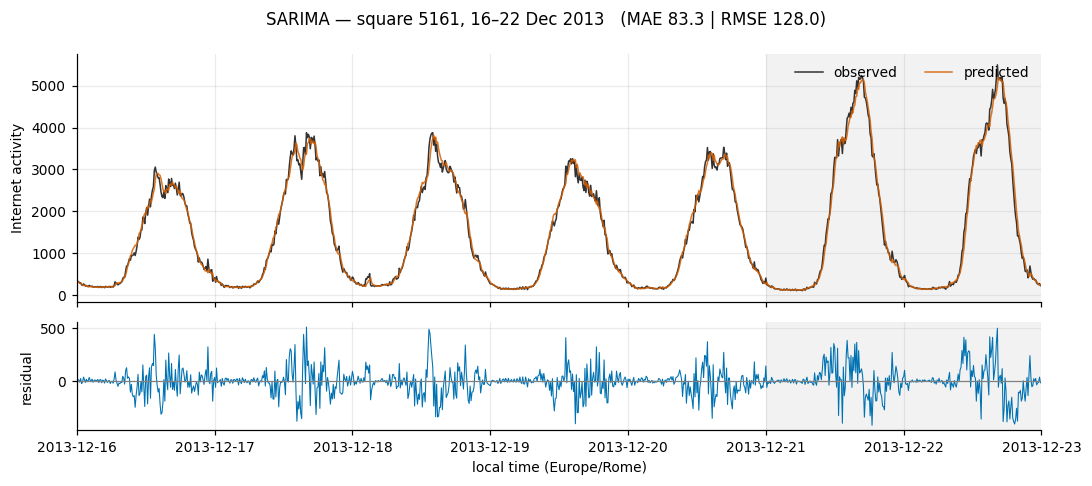

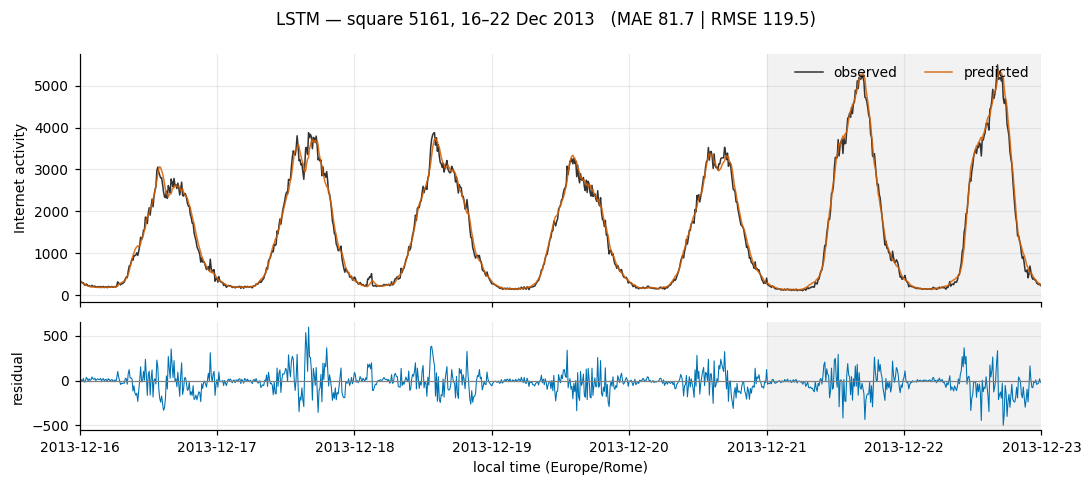

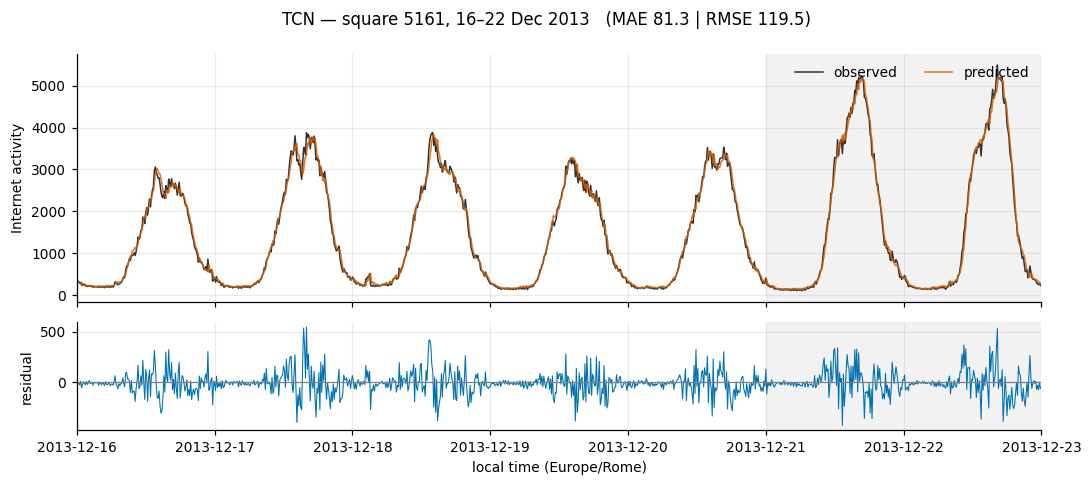

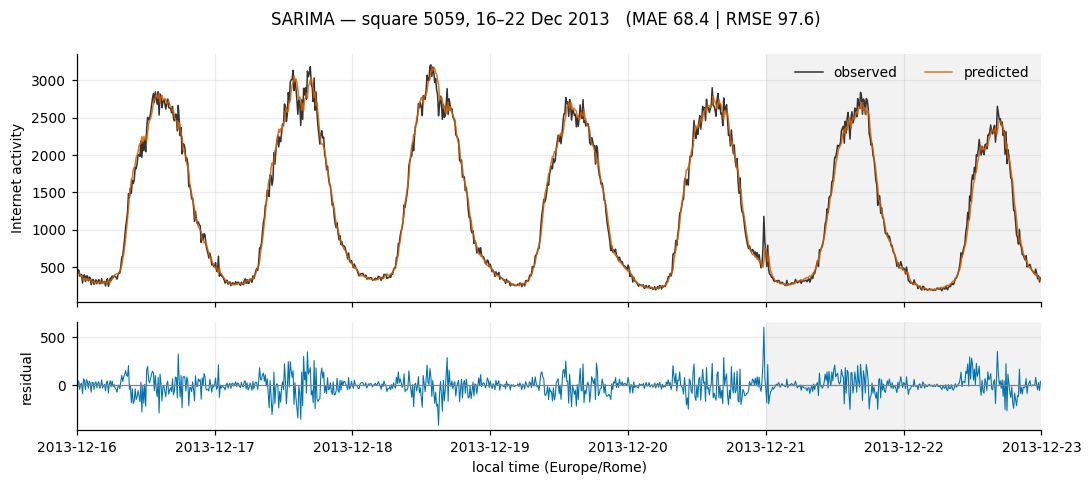

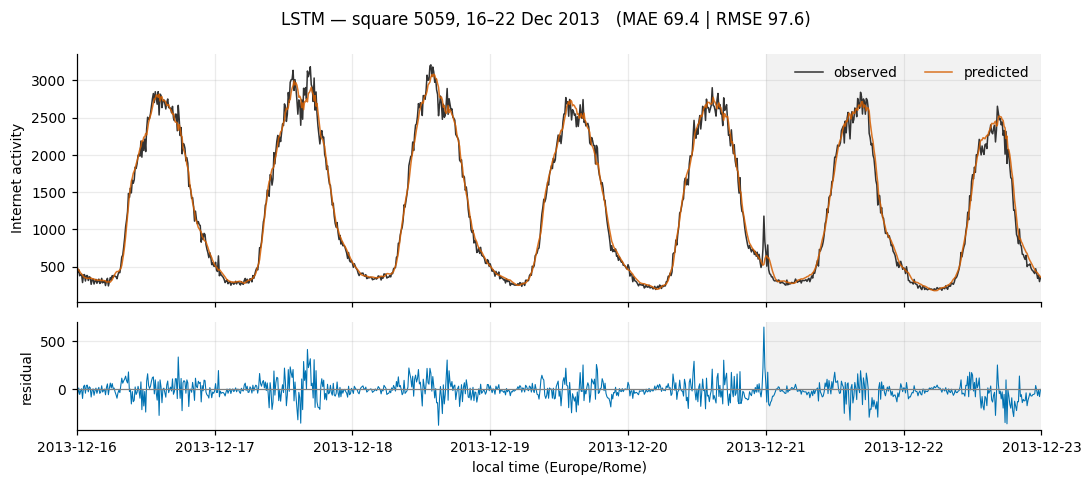

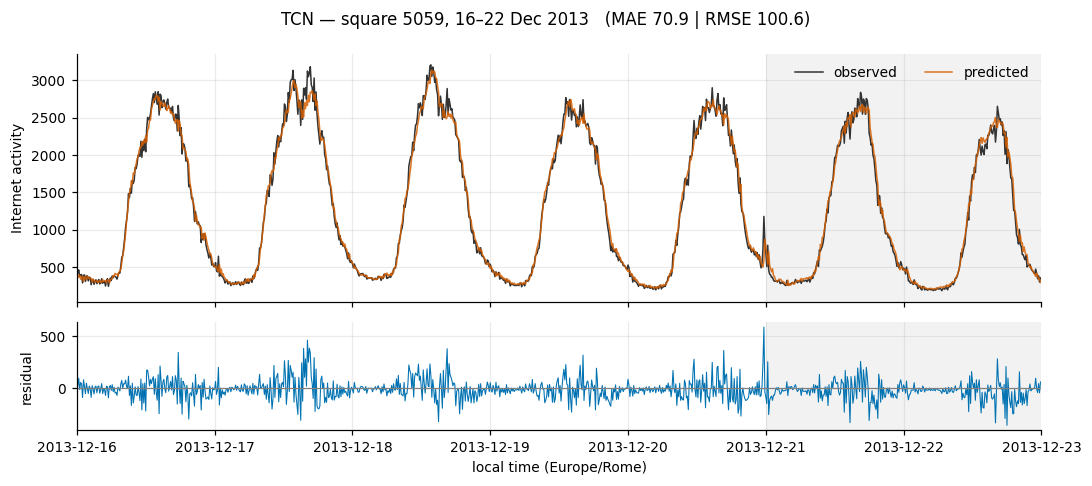

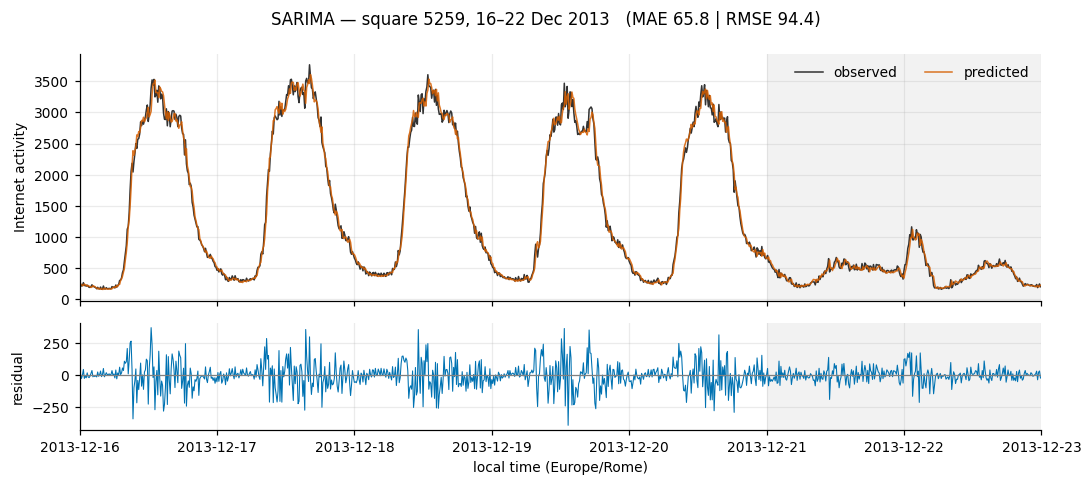

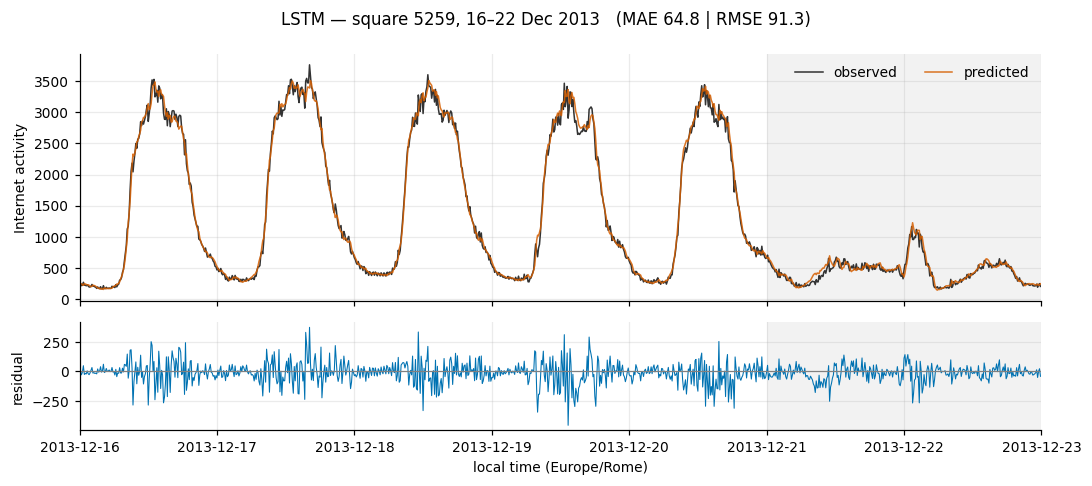

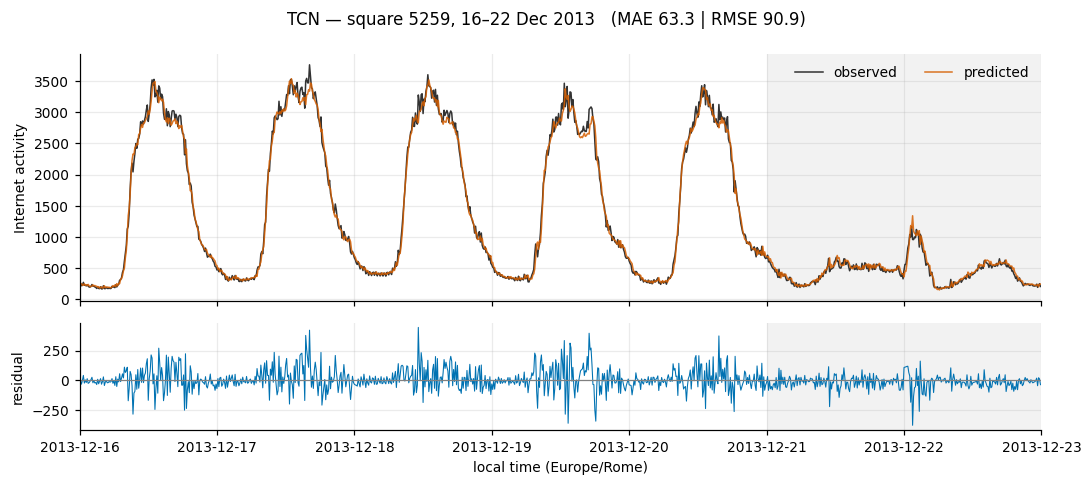

all forecast figures saved to Drive


In [21]:
test_index = full_index[FINAL_SPLIT["test"][0]:FINAL_SPLIT["test"][1]]

def plot_forecast(index, truth, preds, title, area):
    fig, (ax, axr) = plt.subplots(2, 1, figsize=(10, 4.4), sharex=True,
                                  gridspec_kw={"height_ratios":[2.3,1]})
    ax.plot(index, truth, color=ACTUAL, lw=1.0, label="observed")
    ax.plot(index, preds, color=PREDICTED, lw=1.0, alpha=0.85, label="predicted")
    ax.legend(loc="upper right", ncols=2); ax.set_ylabel("Internet activity"); ax.margins(x=0)
    resid = truth - preds
    axr.plot(index, resid, color=PALETTE[0], lw=0.7); axr.axhline(0, color="grey", lw=0.8)
    axr.set(ylabel="residual", xlabel="local time (Europe/Rome)"); axr.margins(x=0)
    for day in pd.date_range(index[0].normalize(), index[-1], freq="D"):
        if day.dayofweek >= 5:
            for a in (ax, axr): a.axvspan(day, day+pd.Timedelta(days=1), color="grey", alpha=0.10, lw=0)
    fig.suptitle(f"{title} — square {area}, 16–22 Dec 2013   "
                 f"(MAE {np.mean(np.abs(resid)):,.1f} | RMSE {np.sqrt(np.mean(resid**2)):,.1f})", y=0.99)
    fig.tight_layout(); return fig

STUDIED = ["SARIMA", "LSTM", "TCN"]
for area in TOP3:                      # the three required areas; others saved but not displayed
    for fam in STUDIED:
        fig = plot_forecast(test_index, per_area_preds[area]["truth"], per_area_preds[area][fam], fam, area)
        save(fig, f"forecast_sq{area}_{fam}"); plt.show()
for area in [a for a in AREAS if a not in TOP3]:
    for fam in STUDIED:
        fig = plot_forecast(test_index, per_area_preds[area]["truth"], per_area_preds[area][fam], fam, area)
        save(fig, f"forecast_sq{area}_{fam}"); plt.close(fig)
print("all forecast figures saved to Drive")

### 6.3 Training and execution time *(brief §4.IV)*

In [22]:
summary = (timing_df.groupby("family")
           .agg(train_s_mean=("train_s","mean"), train_s_std=("train_s","std"),
                predict_s_mean=("predict_s","mean"), ms_per_forecast=("ms_per_forecast","mean"),
                n_params=("n_params","first"), epochs_mean=("epochs","mean"))
           .round(3).sort_values("train_s_mean"))
print(f"Averaged over {len(AREAS)} areas. Wall-clock, identical instrumentation for every model.")
print(f"Hardware: {'GPU ' + gpus[0].name if gpus else 'CPU only'} | TensorFlow {tf.__version__}")
print(summary.to_string())
summary.to_csv(os.path.join(RES_DIR, "final_timings_summary.csv"))
timing_df.to_csv(os.path.join(RES_DIR, "final_timings_per_area.csv"), index=False)
summary

Averaged over 5 areas. Wall-clock, identical instrumentation for every model.
Hardware: GPU /physical_device:GPU:0 | TensorFlow 2.20.0
               train_s_mean  train_s_std  predict_s_mean  ms_per_forecast  n_params  epochs_mean
family                                                                                          
Persistence           0.000        0.000           0.000            0.000       NaN          NaN
SeasonalNaive         0.000        0.000           0.000            0.000       NaN          NaN
SARIMA               12.061        0.434           0.080            0.079      14.0          NaN
TCN                  39.125        9.589           1.737            1.724    5601.0         47.8
LSTM                 50.116       23.822           0.281            0.278   16961.0         56.2


,train_s_mean,train_s_std,predict_s_mean,ms_per_forecast,n_params,epochs_mean
family,,,,,,
Persistence,0.000,0.000,0.000,0.000,NaN,NaN
SeasonalNaive,0.000,0.000,0.000,0.000,NaN,NaN
SARIMA,12.061,0.434,0.080,0.079,14.0,NaN
TCN,39.125,9.589,1.737,1.724,5601.0,47.8
LSTM,50.116,23.822,0.281,0.278,16961.0,56.2


### 6.4 Does the ranking hold across areas? *(brief §4.VII — the research question)*

area            4159    4556    5059    5161    5259  mean_rank
family                                                         
LSTM           19.24   38.48   97.62  119.54   91.33        1.8
SARIMA         19.01   34.17   97.64  127.95   94.40        2.0
TCN            20.85   38.75  100.63  119.48   90.94        2.2
Persistence    21.54   39.62  114.38  134.88  109.58        4.0
SeasonalNaive  84.64  108.35  245.87  619.04  861.62        5.0


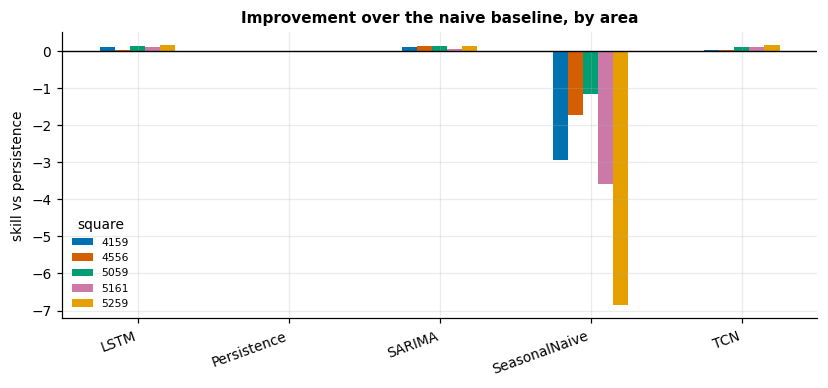

In [23]:
wide = results_df.pivot(index="family", columns="area", values="RMSE").round(2)
wide["mean_rank"] = results_df.pivot(index="family", columns="area", values="RMSE").rank(axis=0).mean(axis=1).round(2)
print(wide.sort_values("mean_rank").to_string())
wide.to_csv(os.path.join(RES_DIR, "final_rmse_by_area.csv"))

fig, ax = plt.subplots(figsize=(7.6, 3.6))
results_df.pivot(index="family", columns="area", values="skill_vs_persistence").plot(kind="bar", ax=ax)
ax.axhline(0, color="black", lw=0.9)
ax.set(ylabel="skill vs persistence", xlabel="",
       title="Improvement over the naive baseline, by area")
ax.legend(title="square", fontsize=7); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); save(fig, "skill_by_area"); plt.show()

**Discussion — this answers the research question.**

Read off whether the ordering is **stable** across areas. If it changes, relate the change to the
area characteristics established in notebook 2: volatility (`cv`), how calendar-driven the area is,
the weekend/weekday ratio and the traffic level.

Bars at or below zero are the honest headline: those models did not beat "repeat the last value".

### 6.5 Failure analysis *(required)*

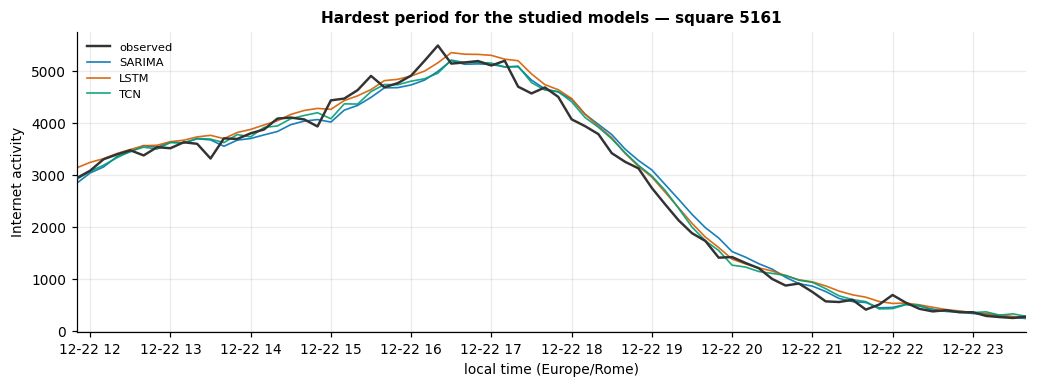

Hardest window: 2013-12-22 11:50:00+01:00  ->  2013-12-22 23:40:00+01:00
        model  MAE_window  MAE_full_week  ratio
       SARIMA     153.752         83.258  1.847
         LSTM     137.448         81.713  1.682
  Persistence     152.950         92.802  1.648
          TCN     126.529         81.271  1.557
SeasonalNaive     257.654        338.594  0.761


In [24]:
def failure_analysis(index, preds, area, window=36):
    truth = preds["truth"]
    studied = {k: v for k, v in preds.items() if k in STUDIED}
    # Score by error relative to each model's OWN mean error, so the search finds periods that are
    # genuinely hard rather than merely busy.
    norm = np.mean([np.abs(truth-p)/max(np.mean(np.abs(truth-p)), 1e-9) for p in studied.values()], axis=0)
    centre = int(pd.Series(norm).rolling(window, center=True).mean().idxmax())
    lo_, hi_ = max(0, centre-window), min(len(truth), centre+window)

    fig, ax = plt.subplots(figsize=(9.5, 3.6))
    ax.plot(index[lo_:hi_], truth[lo_:hi_], color=ACTUAL, lw=1.6, label="observed", zorder=3)
    for (n, p), c in zip(studied.items(), PALETTE):
        ax.plot(index[lo_:hi_], p[lo_:hi_], color=c, lw=1.1, alpha=0.9, label=n)
    ax.legend(loc="upper left", fontsize=7.5)
    ax.set(title=f"Hardest period for the studied models — square {area}",
           ylabel="Internet activity", xlabel="local time (Europe/Rome)")
    ax.margins(x=0); fig.tight_layout()

    tab = pd.DataFrame([{"model": n,
                         "MAE_window": float(np.mean(np.abs(truth[lo_:hi_]-p[lo_:hi_]))),
                         "MAE_full_week": float(np.mean(np.abs(truth-p))),
                         "ratio": float(np.mean(np.abs(truth[lo_:hi_]-p[lo_:hi_])) /
                                        max(np.mean(np.abs(truth-p)), 1e-9))}
                        for n, p in preds.items() if n != "truth"]).sort_values("ratio", ascending=False)
    return fig, tab, (index[lo_], index[hi_-1])

for area in TOP3[:1]:
    fig, tab, win = failure_analysis(test_index, per_area_preds[area], area)
    save(fig, f"failure_sq{area}"); plt.show()
    print(f"Hardest window: {win[0]}  ->  {win[1]}")
    print(tab.round(3).to_string(index=False))
    tab.to_csv(os.path.join(RES_DIR, f"failure_analysis_sq{area}.csv"), index=False)

**Discussion.** Check the identified window against two things from notebook 2:

1. the **anomaly dates** flagged by the MSTL residual screen, and
2. the **calendar** — 16–22 December runs into the Christmas period, and the MSTL trend falls
   roughly 45% between 9 and 27 December.

The models were trained on data ending 15 December. A model conditioned only on recent history has
no mechanism to know a holiday is approaching, and that is the honest explanation for a large class
of these errors — not a defect in any particular architecture. Note which model degrades *least*,
and whether that is the same model that wins on the full week.

## 7. Persist everything

In [25]:
results_df.to_csv(os.path.join(RES_DIR, "final_metrics_long.csv"), index=False)
pd.DataFrame(EXPERIMENTS).to_csv(os.path.join(RES_DIR, "experiments.csv"), index=False)
seed_df.to_csv(os.path.join(RES_DIR, "seed_variance_runs.csv"), index=False)
seed_summary.to_csv(os.path.join(RES_DIR, "seed_variance_summary.csv"))
json.dump({"sarima": build_best_sarima().name,
           "lstm": build_best_lstm().name,
           "tcn": build_best_tcn().name,
           "n_tuning_runs": len(EXPERIMENTS),
           "accelerator": (gpus[0].name if gpus else "CPU only"),
           "tensorflow": tf.__version__},
          open(os.path.join(RES_DIR, "best_configs.json"), "w"), indent=2)

for area, p in per_area_preds.items():
    np.savez_compressed(os.path.join(RES_DIR, f"predictions_sq{area}.npz"),
                        timestamps=test_index.astype("int64").to_numpy(), **p)

print("Saved to", RES_DIR)
for f in sorted(os.listdir(RES_DIR)): print("  ", f)

Saved to /content/drive/MyDrive/milan_traffic_project/results
   best_configs.json
   experiments.csv
   failure_analysis_sq5161.csv
   final_metrics_long.csv
   final_metrics_sq4159.csv
   final_metrics_sq4556.csv
   final_metrics_sq5059.csv
   final_metrics_sq5161.csv
   final_metrics_sq5259.csv
   final_rmse_by_area.csv
   final_timings_per_area.csv
   final_timings_summary.csv
   predictions_sq4159.npz
   predictions_sq4556.npz
   predictions_sq5059.npz
   predictions_sq5161.npz
   predictions_sq5259.npz
   seed_variance_runs.csv
   seed_variance_summary.csv


## 8. Conclusions

Write these from the evidence above, not from expectation:

1. **Which model wins, by how much, and does it hold across areas?** If the ordering changes, tie the
   change to the area characteristics from notebook 2.
2. **Accuracy versus cost.** The RMSE ranking and the training-time ranking are probably different.
   Which would you actually deploy, and why?
3. **What the naive baseline revealed** about the difficulty of the task. If the trained models beat
   persistence by only a few percent, say so — the EDA predicted it, since only a few percent of the
   variance is non-calendar.
4. **What the seed-variance check invalidated.** Report which tuning conclusions survive and which do
   not.
5. **Limitations** — single area per model, univariate, one city, two months, hyperparameters tuned
   on one area and transferred, and an evaluation week sitting on a regime change.
6. **Future work** — spatio-temporal models exploiting the grid, longer horizons, cross-area transfer.